In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
# Load preprocessed data
X = pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/preprocessed_features.csv')
y = pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/target_binary.csv').squeeze()

In [5]:
try:
    pca_model = joblib.load('/content/drive/MyDrive/datasets/Heart_Disease_Project/pca_model.pkl')
    print(f"Loaded your PCA model: {pca_model.n_components} components explain ~90% variance.")
    X_pca = pca_model.transform(X)  # Transform to PCA space
    print(f"PCA-reduced X shape: {X_pca.shape}")
except FileNotFoundError:
    print("PCA model not found - skipping PCA reduction (use full features).")
    pca_model = None
    X_pca = None


Loaded your PCA model: 9 components explain ~90% variance.
PCA-reduced X shape: (303, 9)


In [6]:
# KMeans: Find optimal k (elbow method + silhouette)
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, clusters))

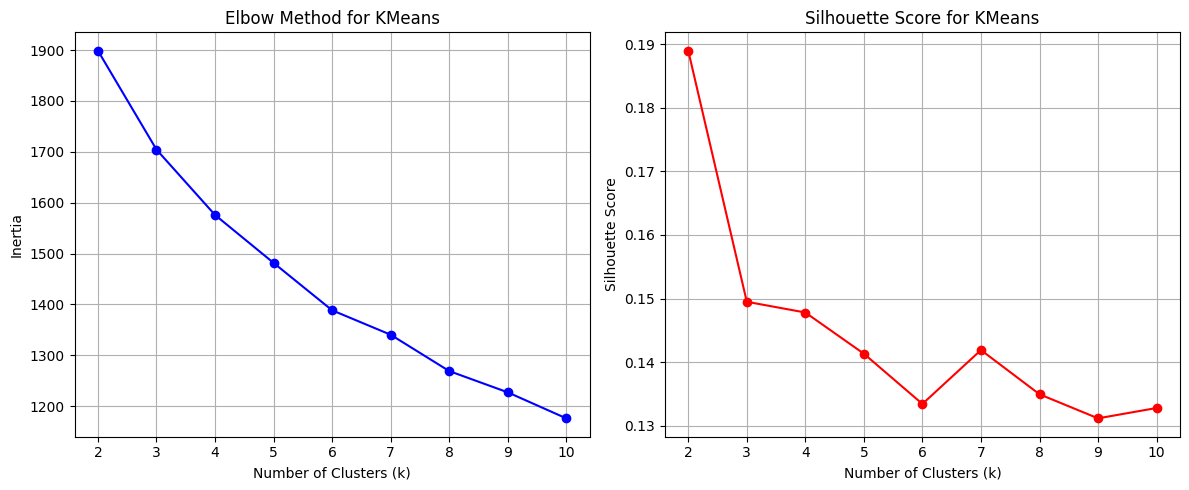

In [7]:
# Plot Elbow and Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for KMeans')
ax1.grid(True)
ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for KMeans')
ax2.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# Choose optimal k
optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal k: {optimal_k} (Silhouette: {max(sil_scores):.3f})")

Optimal k: 2 (Silhouette: 0.189)


In [9]:
# Fit final KMeans
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans_final.fit_predict(X_pca)

In [10]:
# Evaluate: Silhouette and ARI (vs. binary target)
sil_final = silhouette_score(X_pca, kmeans_clusters)
ari_final = adjusted_rand_score(y, kmeans_clusters)
print(f"Final Silhouette: {sil_final:.3f}, ARI (vs. binary target): {ari_final:.3f}")

Final Silhouette: 0.189, ARI (vs. binary target): 0.280


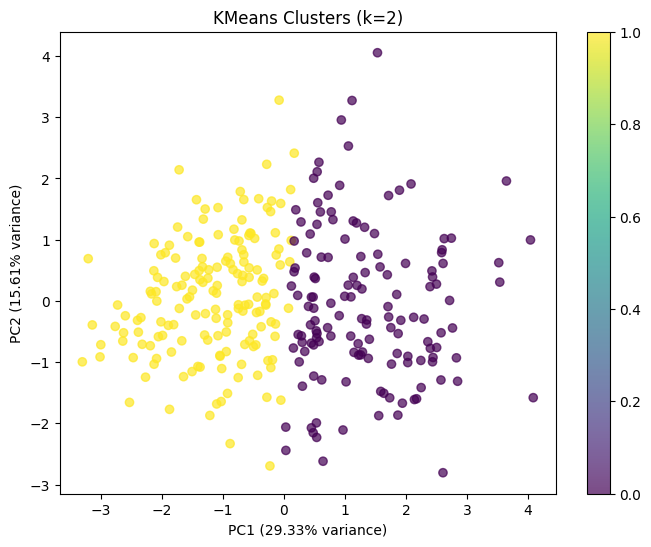

In [11]:
# Plot clusters (PCA for 2D viz)
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_pca)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=kmeans_clusters, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'KMeans Clusters (k={optimal_k})')
plt.colorbar(scatter)
plt.show()

In [12]:
# Hierarchical Clustering (Agglomerative, Ward linkage)
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hc_clusters = hc.fit_predict(X_pca)

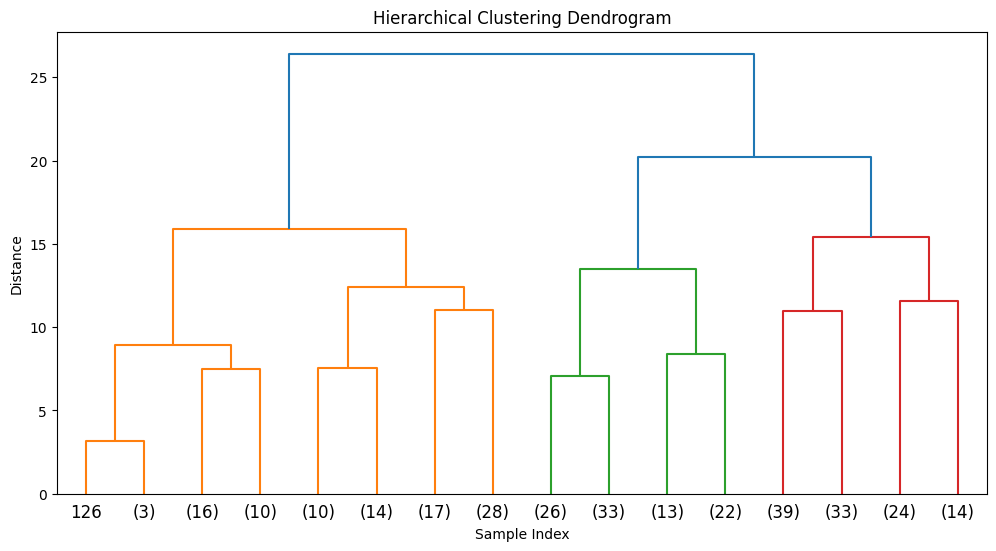

In [13]:
# Dendrogram (for full data; subsample if too large)
Z = linkage(X_pca, 'ward')  # Linkage matrix
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=3)  # Truncate for readability
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [14]:
# Evaluate
sil_hc = silhouette_score(X_pca, hc_clusters)
ari_hc = adjusted_rand_score(y, hc_clusters)
print(f"Hierarchical Silhouette: {sil_hc:.3f}, ARI: {ari_hc:.3f}")

Hierarchical Silhouette: 0.167, ARI: 0.173


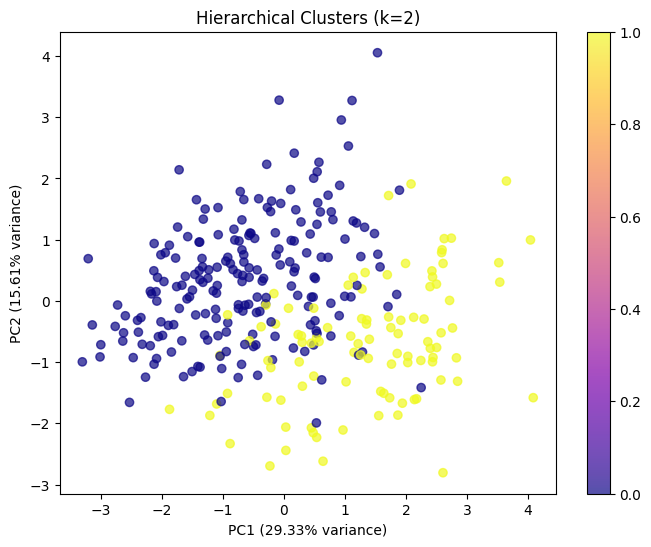

In [15]:
# PCA viz for HC clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=hc_clusters, cmap='plasma', alpha=0.7)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Hierarchical Clusters (k={optimal_k})')
plt.colorbar(scatter)
plt.show()


In [16]:
# Save best model
best_model = kmeans_final
joblib.dump(best_model, '/content/drive/MyDrive/datasets/Heart_Disease_Project/final_model_clustering.pkl')


['/content/drive/MyDrive/datasets/Heart_Disease_Project/final_model_clustering.pkl']